# Conditional Moment Restrictions: Nonlinear IV DGP

This notebook reproduces the nonlinear instrumental-variables data-generating process used in the `conditional-moment-restrictions` demo and fits the lightweight PyTorch CMR estimators added to Trex.

The structural function is $f_0(x) = 2\log(|x| + 0.5)$. The treatment is endogenous because an unobserved $U$ enters both $X$ and $Y$, while the instrument $Z$ shifts $X$ but has no direct effect on $Y$.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from trex import MaximumMomentRestriction, SieveMinimumDistance
from trex.cmr import hsic, mmr_loss

torch.set_num_threads(1)
np.random.seed(42)
_ = torch.manual_seed(42)

## Data-Generating Process

The DGP follows the CMR repository's `demo_all_methods.py`:

$$U \sim N(0, 1), \quad Z \sim \operatorname{Uniform}(-3, 3)$$

$$X = Z + U + \epsilon_x$$

$$Y = 2\log(|X| + 0.5) + U + \epsilon_y$$

In [2]:
def generate_nonparametric_iv_data(n, seed):
    rng = np.random.default_rng(seed)
    u = rng.normal(0.0, 1.0, size=(n, 1)).astype("float32")
    z = rng.uniform(-3.0, 3.0, size=(n, 1)).astype("float32")
    eps_x = rng.normal(0.0, 0.1, size=(n, 1)).astype("float32")
    eps_y = rng.normal(0.0, 0.1, size=(n, 1)).astype("float32")
    x = z + u + eps_x
    y = true_structural_function(x).astype("float32") + u + eps_y
    return {"t": x, "y": y, "z": z, "u": u}


def true_structural_function(x):
    return 2.0 * np.log(np.abs(x) + 0.5)


train = generate_nonparametric_iv_data(500, seed=42)
test = generate_nonparametric_iv_data(2000, seed=44)

t_train = torch.tensor(train["t"])
y_train = torch.tensor(train["y"])
z_train = torch.tensor(train["z"])

x_grid = np.linspace(
    np.percentile(test["t"], 1),
    np.percentile(test["t"], 99),
    300,
    dtype="float32",
)[:, None]
x_grid_t = torch.tensor(x_grid)
f_grid = torch.tensor(true_structural_function(x_grid).astype("float32"))

print(f"train n={len(t_train)}, test n={len(test['t'])}")
print(f"corr(X, U)={np.corrcoef(train['t'].ravel(), train['u'].ravel())[0, 1]:.3f}")
print(f"corr(Z, U)={np.corrcoef(train['z'].ravel(), train['u'].ravel())[0, 1]:.3f}")

train n=500, test n=2000
corr(X, U)=0.473
corr(Z, U)=-0.007


## Estimators

The baseline is a neural least-squares fit of $Y$ on $X$, which is biased here because $E[U \mid X] \neq 0$. The CMR estimators use the residual moment $\psi_\theta(X,Y)=f_\theta(X)-Y$ and the instrument condition $E[\psi_\theta(X,Y) \mid Z] = 0$.

In [3]:
def make_network():
    return torch.nn.Sequential(
        torch.nn.Linear(1, 64),
        torch.nn.Tanh(),
        torch.nn.Linear(64, 32),
        torch.nn.Tanh(),
        torch.nn.Linear(32, 1),
    )


def residual_moment(prediction, y):
    return prediction - y


def train_least_squares(model, steps=1200, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        optimizer.zero_grad()
        loss = torch.mean((model(t_train) - y_train).square())
        loss.backward()
        optimizer.step()
    return model


def clone_model(model):
    cloned = make_network()
    cloned.load_state_dict(model.state_dict())
    return cloned


ols_model = train_least_squares(make_network())

mmr = MaximumMomentRestriction(
    model=clone_model(ols_model),
    moment_function=residual_moment,
    optimizer=torch.optim.Adam,
    lr=2e-3,
    maxiter=1200,
    device="cpu",
)
mmr.fit(t_train, y_train, z_train)

smd = SieveMinimumDistance(
    model=clone_model(ols_model),
    moment_function=residual_moment,
    optimizer=torch.optim.Adam,
    lr=2e-3,
    maxiter=1200,
    degree=5,
    device="cpu",
)
_ = smd.fit(t_train, y_train, z_train)

In [4]:
def evaluate(name, model):
    with torch.no_grad():
        grid_mse = torch.mean((model(x_grid_t) - f_grid).square()).item()
        residual = model(t_train) - y_train
        cond_loss = mmr_loss(residual, z_train).item()
        residual_hsic = hsic(residual, z_train).item()
    return {
        "name": name,
        "grid_mse_to_true_f": grid_mse,
        "mmr_loss": cond_loss,
        "hsic_residual_z": residual_hsic,
    }


results = [
    evaluate("Neural least squares", ols_model),
    evaluate("MMR", mmr.model),
    evaluate("Polynomial SMD", smd.model),
]

header = f"{'estimator':<22} {'grid MSE':>12} {'MMR loss':>12} {'HSIC':>12}"
print(header)
print("-" * len(header))
for row in results:
    print(
        f"{row['name']:<22} "
        f"{row['grid_mse_to_true_f']:>12.4f} "
        f"{row['mmr_loss']:>12.6f} "
        f"{row['hsic_residual_z']:>12.6f}"
    )

estimator                  grid MSE     MMR loss         HSIC
-------------------------------------------------------------
Neural least squares         0.4849     0.031391     0.010570
MMR                          0.0476     0.000007     0.001178
Polynomial SMD               0.0891     0.000007     0.001983


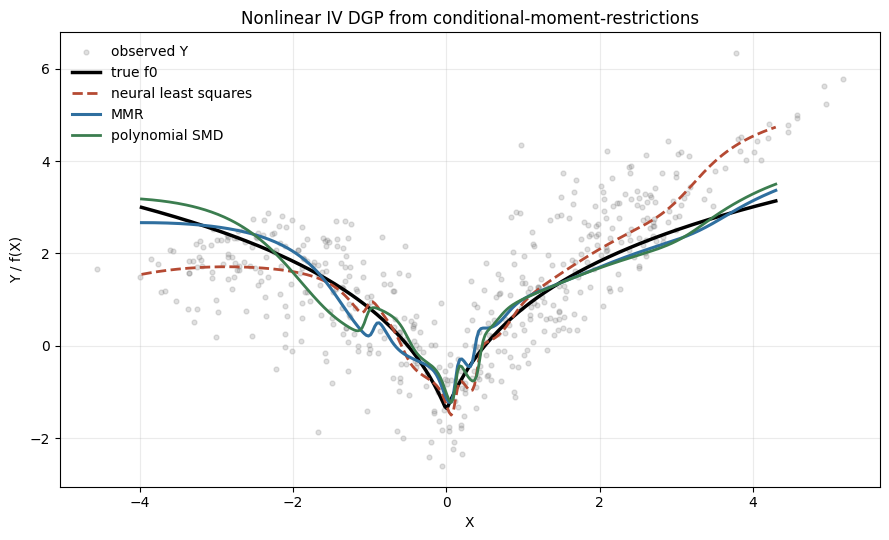

In [5]:
with torch.no_grad():
    pred_ols = ols_model(x_grid_t).numpy()
    pred_mmr = mmr.predict(x_grid_t).numpy()
    pred_smd = smd.predict(x_grid_t).numpy()

fig, ax = plt.subplots(figsize=(9, 5.5))
sample = np.random.default_rng(7).choice(len(test["t"]), size=500, replace=False)
ax.scatter(
    test["t"][sample],
    test["y"][sample],
    s=12,
    alpha=0.22,
    color="0.45",
    label="observed Y",
)
ax.plot(x_grid, true_structural_function(x_grid), color="black", lw=2.5, label="true f0")
ax.plot(x_grid, pred_ols, color="#b54a33", lw=2, ls="--", label="neural least squares")
ax.plot(x_grid, pred_mmr, color="#2f6f9f", lw=2.2, label="MMR")
ax.plot(x_grid, pred_smd, color="#3b7d4f", lw=2, label="polynomial SMD")
ax.set_title("Nonlinear IV DGP from conditional-moment-restrictions")
ax.set_xlabel("X")
ax.set_ylabel("Y / f(X)")
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="best")
fig.tight_layout()